# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Devina Kartika
- **Email:** devina.123140036@student.itera.ac.id
- **ID Dicoding:** CDCC119D6X2329

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Kategori produk apa yang paling banyak dan paling sedikit terjual?

- Pertanyaan 2: Bagaimana demografi persebaran pelanggan yang kita miliki berdasarkan negara bagian (state)?

## Import Semua Packages/Library yang Digunakan

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mengatur tema visualisasi
sns.set_theme(style="darkgrid")

## Data Wrangling

### Gathering Data

In [12]:
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")
customers_df = pd.read_csv("customers_dataset.csv")

orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Data yang akan digunakan difokuskan pada 4 tabel utama: orders, order_items, products, dan customers.

- Keempat tabel ini memiliki primary key dan foreign key yang bisa digabungkan nanti (seperti order_id yang ada di tabel orders dan order_items).

### Assessing Data

In [13]:
# Memeriksa tabel orders
print("--- INFO ORDERS ---")
orders_df.info()
print("\nMissing values orders_df:\n", orders_df.isna().sum())
print("\nDuplikat orders_df:", orders_df.duplicated().sum())

# Memeriksa tabel order_items
print("\n\n--- INFO ORDER ITEMS ---")
order_items_df.info()
print("\nMissing values order_items_df:\n", order_items_df.isna().sum())
print("\nDuplikat order_items_df:", order_items_df.duplicated().sum())

# Memeriksa tabel products
print("\n\n--- INFO PRODUCTS ---")
products_df.info()
print("\nMissing values products_df:\n", products_df.isna().sum())
print("\nDuplikat products_df:", products_df.duplicated().sum())

# Memeriksa tabel customers
print("\n\n--- INFO CUSTOMERS ---")
customers_df.info()
print("\nMissing values customers_df:\n", customers_df.isna().sum())
print("\nDuplikat customers_df:", customers_df.duplicated().sum())

--- INFO ORDERS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

Missing values orders_df:
 order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_

**Insight:**
- orders_df: Terdapat missing values pada kolom waktu (seperti order_approved_at, order_delivered_carrier_date, order_delivered_customer_date). Tipe data waktu (tanggal) juga masih berupa object/string dan harus diubah ke format datetime.

- order_items_df: Tidak ada missing value. Data cukup bersih.

- products_df: Terdapat missing values pada kolom product_category_name (sekitar 610 baris kosong). Kita perlu mengisinya atau menghapusnya nanti di tahap pembersihan.

- customers_df: Tidak ada missing value. Seluruh data geografis pelanggan (city, state) sudah lengkap.

- Secara umum, tidak ada data duplikat di keempat tabel yang kita gunakan.

### Cleaning Data

In [14]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

products_df["product_category_name"].fillna('unknown', inplace=True)

orders_df.drop_duplicates(inplace=True)
customers_df.drop_duplicates(inplace=True)

orders_df.info()

/tmp/ipykernel_15886/1222275780.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna('unknown', inplace=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


**Insight:**
- Kolom yang berkaitan dengan waktu pada orders_df telah berhasil diubah menjadi tipe data datetime. Ini penting agar nantinya kita bisa melakukan analisis berbasis waktu (seperti tren bulanan).

- Nilai kosong pada kolom kategori produk di products_df telah diisi dengan label 'unknown' agar data tersebut tidak hilang saat dilakukan pengelompokan (grouping), namun tetap teridentifikasi sebagai data tanpa kategori.

## Exploratory Data Analysis (EDA)

### Explore ...

In [15]:
product_counts_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

category_performance_df = product_counts_df.groupby("product_category_name").product_id.count().reset_index()
category_performance_df.rename(columns={"product_id": "order_count"}, inplace=True)
category_performance_df = category_performance_df.sort_values(by="order_count", ascending=False)

print("Top 5 Kategori Produk:")
print(category_performance_df.head())

customer_demographics_df = customers_df.groupby("customer_state").customer_id.nunique().reset_index()
customer_demographics_df.rename(columns={"customer_id": "customer_count"}, inplace=True)
customer_demographics_df = customer_demographics_df.sort_values(by="customer_count", ascending=False)

print("\nDemografi Pelanggan berdasarkan State:")
print(customer_demographics_df.head())

Top 5 Kategori Produk:
     product_category_name  order_count
13         cama_mesa_banho        11115
11            beleza_saude         9670
32           esporte_lazer         8641
54        moveis_decoracao         8334
44  informatica_acessorios         7827

Demografi Pelanggan berdasarkan State:
   customer_state  customer_count
25             SP           41746
18             RJ           12852
10             MG           11635
22             RS            5466
17             PR            5045


**Insight:**
- Melalui penggabungan tabel order_items dan products, terlihat bahwa terdapat dominasi kategori produk tertentu yang memiliki angka penjualan jauh lebih tinggi dibanding kategori lainnya.

- Dari sisi demografi, mayoritas pelanggan terkonsentrasi di negara bagian tertentu. Hal ini menunjukkan adanya ketimpangan pasar secara geografis yang bisa menjadi masukan bagi tim pemasaran untuk melakukan ekspansi atau optimasi logistik di wilayah lain.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_15886/3594568170.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_count", y="product_category_name", data=category_performance_df.head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_15886/3594568170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="order_count", y="product_category_name", data=category_performance_df.sort_values(by="order_count", ascending=True).head(5), palette=colors, ax=ax[1])


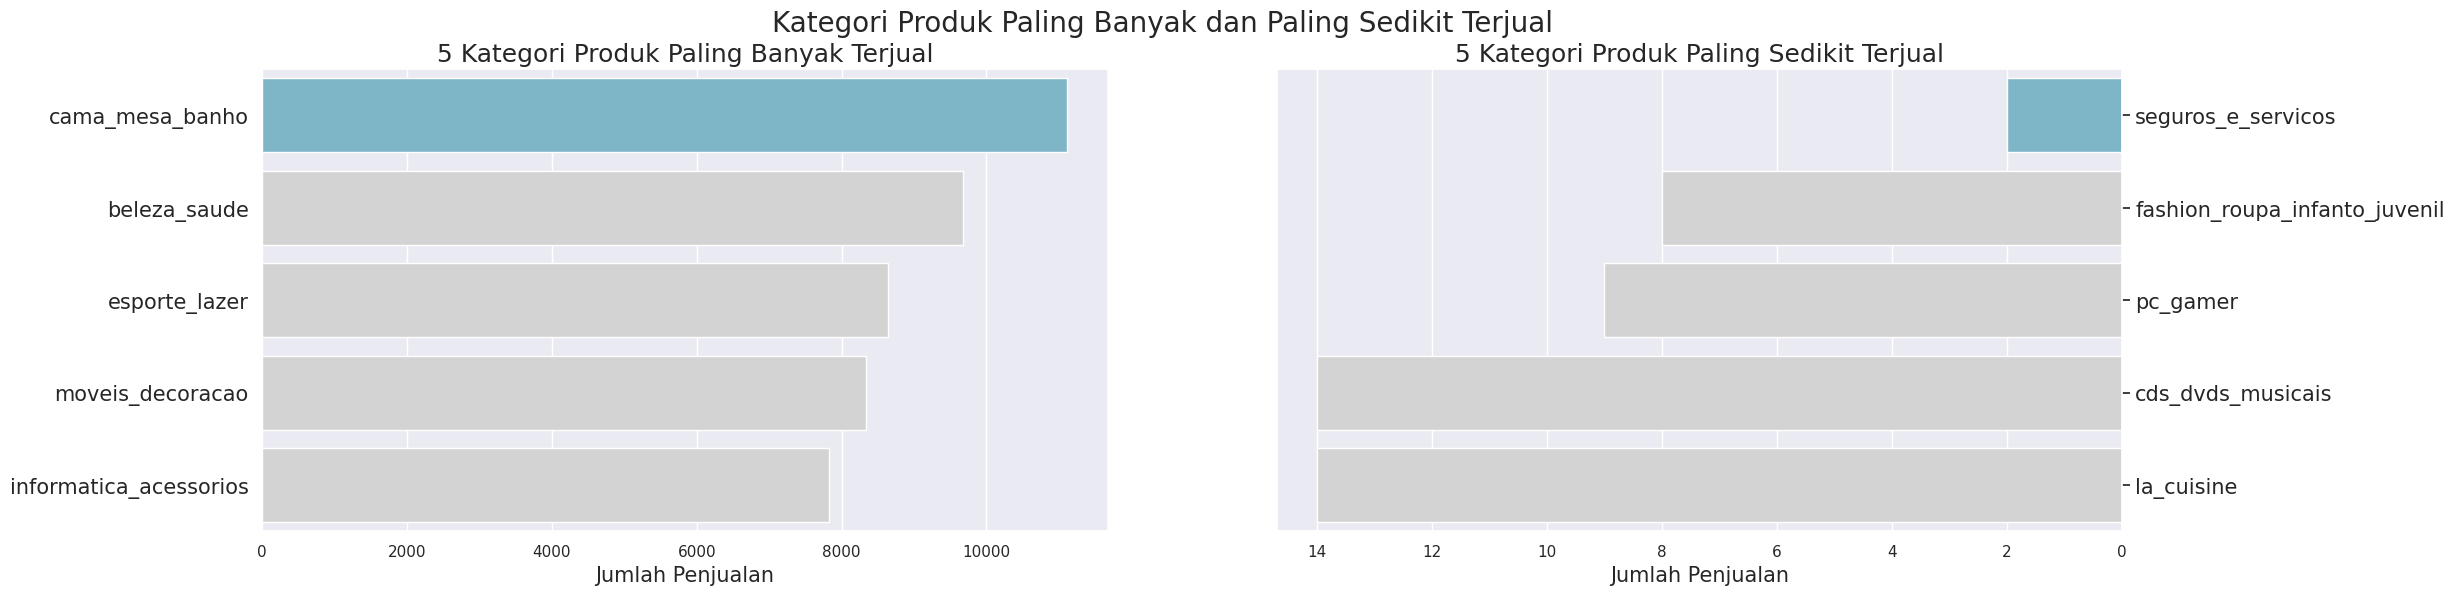

In [16]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="order_count", y="product_category_name", data=category_performance_df.head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel("Jumlah Penjualan", fontsize=15)
ax[0].set_title("5 Kategori Produk Paling Banyak Terjual", loc="center", fontsize=18)
ax[0].tick_params(axis='y', labelsize=15)

sns.barplot(x="order_count", y="product_category_name", data=category_performance_df.sort_values(by="order_count", ascending=True).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel("Jumlah Penjualan", fontsize=15)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("5 Kategori Produk Paling Sedikit Terjual", loc="center", fontsize=18)
ax[1].tick_params(axis='y', labelsize=15)

plt.suptitle("Kategori Produk Paling Banyak dan Paling Sedikit Terjual", fontsize=20)
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_15886/2119005524.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


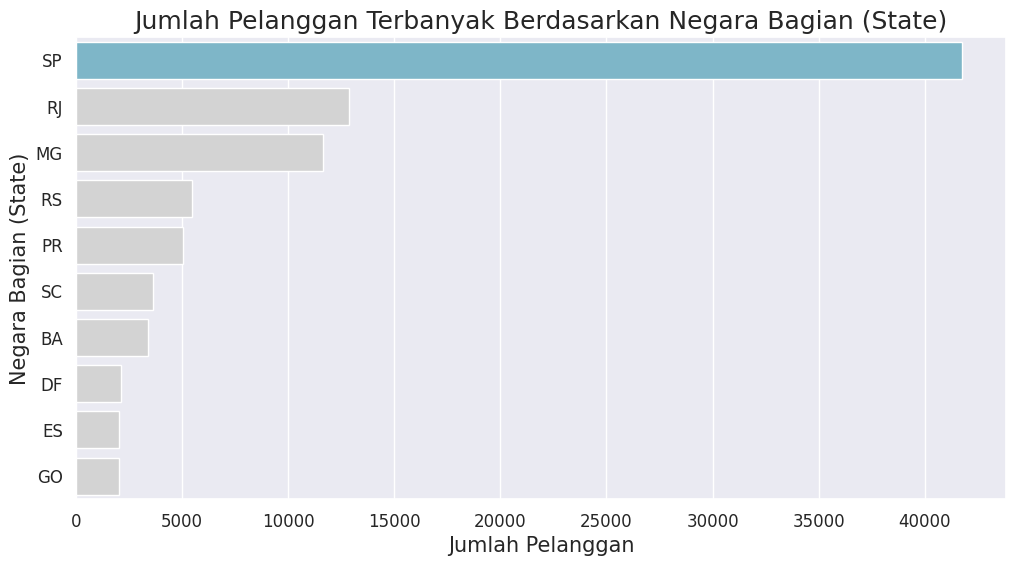

In [17]:
plt.figure(figsize=(12, 6))

top_10_states = customer_demographics_df.head(10)

sns.barplot(
    x="customer_count",
    y="customer_state",
    data=top_10_states,
    palette=["#72BCD4" if i == 0 else "#D3D3D3" for i in range(len(top_10_states))]
)

plt.title("Jumlah Pelanggan Terbanyak Berdasarkan Negara Bagian (State)", fontsize=18)
plt.xlabel("Jumlah Pelanggan", fontsize=15)
plt.ylabel("Negara Bagian (State)", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

**Insight:**
- Pertanyaan 1: Dari visualisasi pertama, terlihat dengan sangat jelas bahwa produk dengan kategori cama_mesa_banho (bed_bath_table) merajai penjualan, jauh melampaui kategori lainnya. Sebaliknya, kategori seperti seguros_e_servicos (security_and_services) sangat sepi peminat dan menjadi kategori dengan penjualan paling rendah.

- Pertanyaan 2: Persebaran demografi pelanggan sangat tidak merata dan terpusat. Pelanggan terbanyak secara masif berada di negara bagian SP (São Paulo), mengalahkan jumlah gabungan dari beberapa negara bagian di bawahnya seperti RJ (Rio de Janeiro) dan MG (Minas Gerais).

## Analisis Lanjutan (Opsional)

In [18]:
rfm_base = pd.merge(orders_df, customers_df, on="customer_id")
rfm_base = pd.merge(rfm_base, order_items_df, on="order_id")

recent_date = rfm_base["order_purchase_timestamp"].dt.date.max() + pd.Timedelta(days=1)

rfm_df = rfm_base.groupby("customer_unique_id").agg({
    "order_purchase_timestamp": lambda x: (recent_date - x.dt.date.max()).days, # Recency
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

rfm_df.columns = ["customer_unique_id", "recency", "frequency", "monetary"]

print("Hasil Analisis RFM (Top 5 Pelanggan berdasarkan Nilai Transaksi / Monetary):")
print(rfm_df.sort_values(by="monetary", ascending=False).head())

Hasil Analisis RFM (Top 5 Pelanggan berdasarkan Nilai Transaksi / Monetary):
                     customer_unique_id  recency  frequency  monetary
3799   0a0a92112bd4c708ca5fde585afaa872      340          1   13440.0
81388  da122df9eeddfedc1dc1f5349a1a690c      521          2    7388.0
44139  763c8b1c9c68a0229c42c9fc6f662b93       51          1    7160.0
82230  dc4802a71eae9be1dd28f5d788ceb526      569          1    6735.0
26015  459bef486812aa25204be022145caa62       41          1    6729.0


**Tujuan Analisis Lanjutan (RFM Analysis):**

Teknik ini dilakukan untuk melakukan segmentasi pelanggan tanpa algoritma machine learning. Kita membagi pelanggan berdasarkan:

- Recency: Berapa hari berlalu sejak terakhir kali pelanggan berbelanja.

- Frequency: Berapa kali pelanggan tersebut melakukan transaksi.

- Monetary: Total uang yang dihabiskan pelanggan selama bertransaksi.
Hal ini sangat berguna bagi tim marketing untuk menargetkan promosi khusus (misal: memberikan diskon untuk pelanggan dengan Frequency tinggi tapi Recency-nya sudah berbulan-bulan yang lalu agar mereka kembali).

## Conclusion

- Berdasarkan analisis performa produk, kategori dengan peminat tertinggi adalah "cama_mesa_banho" (bed_bath_table) dan beberapa kategori alat kecantikan/kesehatan. Di sisi lain, kategori layanan jasa ("seguros_e_servicos") memiliki performa terburuk. Perusahaan sebaiknya memfokuskan strategi pemasaran, ketersediaan stok, dan diskon pada top 5 kategori tersebut karena merupakan penopang utama pendapatan.

- Demografi pasar sangat didominasi oleh negara bagian São Paulo (SP). Ini mengindikasikan bahwa infrastruktur logistik dan pengenalan merek (brand awareness) perusahaan di wilayah SP sudah sangat matang. Namun, ini juga merupakan sinyal bahwa ada potensi pasar yang masih belum tergali secara maksimal di negara bagian lain. Perusahaan dapat melakukan riset pasar lebih lanjut untuk mengetahui mengapa penjualan di luar SP masih tertinggal dan merancang kampanye logistik (misal: subsidi ongkir) untuk wilayah-wilayah tier-2.

In [19]:
all_df = pd.merge(
    left=rfm_base,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

all_df.to_csv("main_data.csv", index=False)